In [3]:
# NOTE (2026-06-03): Removed legacy unpacked variables Y11..Y42 from simulate
# call sites because simulate currently returns only 7 values:
# (time, C_a, C_o, C_v, C_so, Temp, X). Also fixed one call missing index.
# Example before:
# time1, C_a1, C_o1, C_v1, C_so1, Temp1, X1, Y11, Y21, Y31, Y41 = simulate(...)
# Example now:
# time1, C_a1, C_o1, C_v1, C_so1, Temp1, X1 = simulate(...)

# this code is based on 
# https://github.com/Yazdan-Babazadeh/Socio-Climate-model

Running baseline with parameters: {'social_norm': 'Observation-based / imitation', 'C_s0': 1500, 'C_veg0': 550, 'C_at0': 596, 'C_ao0': 150000.0, 'K_a': 1.773e+20, 'K_p': 0.184, 'K_A': 8703900000.0, 'K_mm': 1.478, 'K_c': 2.9e-05, 'K_m': 0.00012, 'T_0': 288.15, 'K_r': 0.092, 'E_a': 54.83, 'R': 8.314, 'K_sr': 0.034, 'K_b': 157.072, 'K_t': 0.092, 'F_0': 0.025, 'xi': 0.3, 'zeta': 50, 'kappa': 0.05, 'beta': 1, 'delta': 1, 'H': 0.5915, 'P_0': 140000000000.0, 'L': 43655, 'A': 0.225, 'S': 1368, 'c': 4.69e+23, 'sigma': 5.67e-08, 'a_E': 510100000000000.0, 'f_max': 5, 'omega': 3, 'T_c': 2.5, 'epsilon_max': 7, 's': 50, 'r_0': 5, 'x0': 0.05, 'f_gtm': 83259000000000.0, 'tp': 10, 'tf': 25}
Running dynamic social norm with parameters: {'social_norm': 'dynamic social norm', 'C_s0': 1500, 'C_veg0': 550, 'C_at0': 596, 'C_ao0': 150000.0, 'K_a': 1.773e+20, 'K_p': 0.184, 'K_A': 8703900000.0, 'K_mm': 1.478, 'K_c': 2.9e-05, 'K_m': 0.00012, 'T_0': 288.15, 'K_r': 0.092, 'E_a': 54.83, 'R': 8.314, 'K_sr': 0.034, '

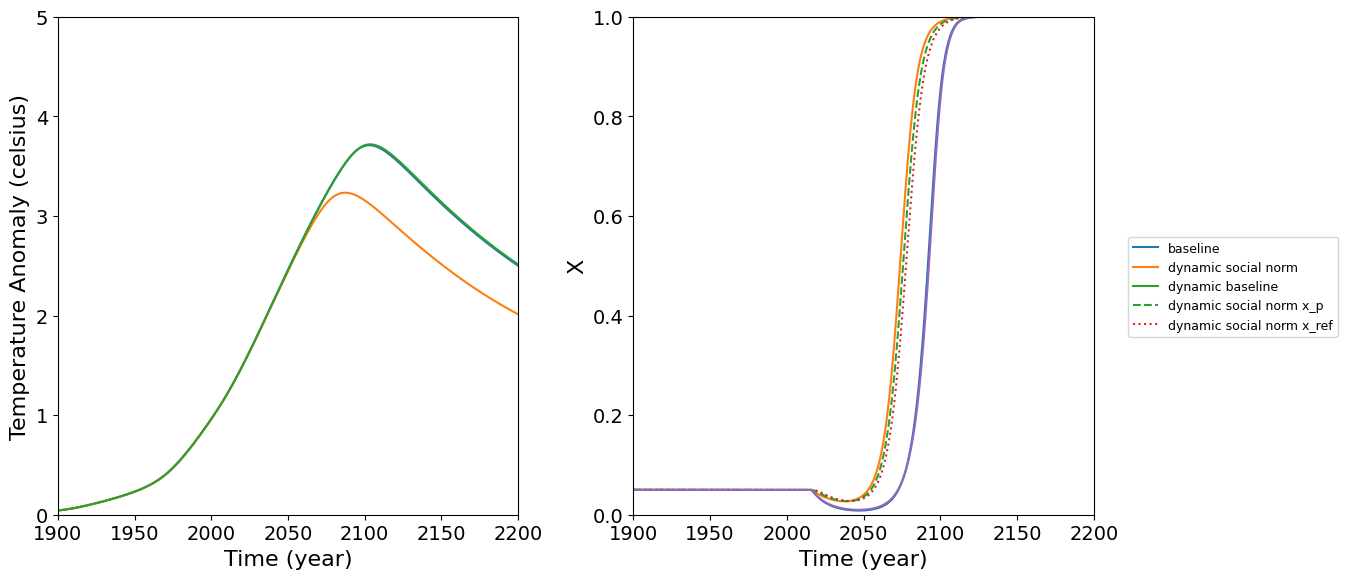

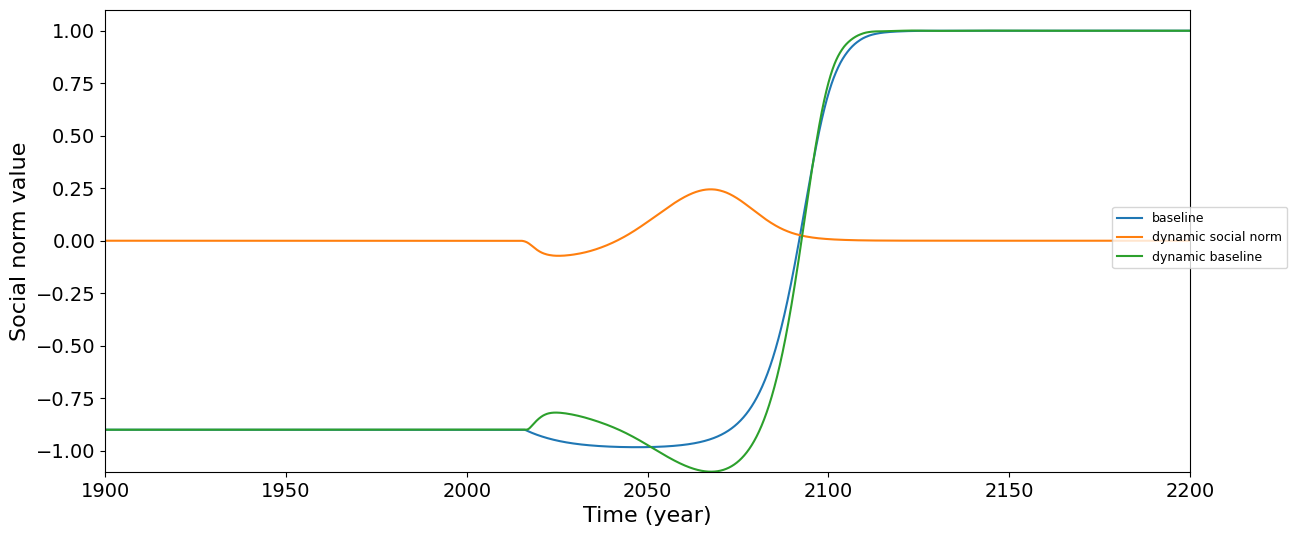

In [1]:
# import importlib
import numpy
import plotting
import numpy as np

# importlib.reload(plotting)

simulation_time = 400

# Standard plot for all scenarios
res = {name: plotting.simulate(name, simulation_time=simulation_time) for name in plotting.load_scenarios(include=["baseline", "dynamic social norm", "dynamic baseline"])}
# res = {name: plotting.simulate(name, simulation_time=simulation_time) for name in plotting.load_scenarios(include=["baseline", "Belief-based / intention motivation"])}
# res = {name: plotting.simulate(name, simulation_time=simulation_time) for name in plotting.load_scenarios()}

scenario_results = {
    name: result["simulation"]
    for name, result in res.items()
}
social_norms = {
    name: result["social_norm_term"]
    for name, result in res.items()
}

# 
x = social_norms["dynamic social norm"]
print(min(x), max(x))

plotting.plot_temperature(results=scenario_results, simulation_time=simulation_time, show_x_auxiliary=True)
plotting.plot_social_norms(results=social_norms, simulation_time=simulation_time, show_x_auxiliary=True)
# plotting.plot_social_norms(results=social_norms, simulation_time=simulation_time, show_x_auxiliary=False, scenarios=["dynamic social norm", "dynamic baseline", "baseline"])

# plotting.plot_temperature_sensitivity("delta", np.arange(0, 1.03, 0.3).tolist())
# plotting.plot_temperature_sensitivity("tau_STref", range(1, 150, 10))
# plotting.plot_temperature_sensitivity("tau_xp", range(1, 150, 10))
